In [65]:
# Install necessary libraries
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Algerian Forest Fires - Regression Analysis

This notebook performs a regression analysis on the Algerian Forest Fires dataset to predict the Fire Weather Index (FWI). The analysis includes data cleaning, exploratory data analysis (EDA), and feature engineering. The final goal is to build a regression model to predict the FWI.
***
## Table of Contents
1.  [Import Libraries](#import-libraries)
2.  [Data Loading and Initial Exploration](#data-loading-and-initial-exploration)
3.  [Data Cleaning](#data-cleaning)
4.  [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
5.  [Feature Engineering and Model Preparation](#feature-engineering-and-model-preparation)
6.  [Model Training](#model-training)
***
<a id="import-libraries"></a>
## 1. Import Libraries


In [66]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<a id="data-loading-and-initial-exploration"></a>
## 2. Data Loading and Initial Exploration

In [67]:
# Load the dataset
dataset = pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)

In [68]:
# Display the first few rows of the dataset
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [69]:
# Get information about the dataset
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.0 KB


<a id="data-cleaning"></a>
## 3. Data Cleaning

### 3.1. Checking for Missing Values

In [70]:
# Check for the sum of null values in each column
dataset.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [71]:
# Check if any column has null values
dataset.isnull().any()

day            False
month           True
year            True
Temperature     True
 RH             True
 Ws             True
Rain            True
FFMC            True
DMC             True
DC              True
ISI             True
BUI             True
FWI             True
Classes         True
dtype: bool

In [72]:
# Display rows with any null values
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


### 3.2. Adding a 'Region' Column

The dataset is divided into two regions: Bejaia and Sidi-Bel Abbes. We will add a 'Region' column to distinguish between them.
- **0**: Bejaia Region
- **1**: Sidi-Bel Abbes Region

In [73]:
# Assign region codes
dataset.loc[:122, 'Region'] = 0
dataset.loc[122:, 'Region'] = 1

In [74]:
# Display the first few rows with the new 'Region' column
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [75]:
# Get information about the dataset again to see the new column
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    str    
 1   month        245 non-null    str    
 2   year         245 non-null    str    
 3   Temperature  245 non-null    str    
 4    RH          245 non-null    str    
 5    Ws          245 non-null    str    
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
 14  Region       246 non-null    float64
dtypes: float64(1), str(14)
memory usage: 29.0 KB


In [76]:
# Convert the 'Region' column to integer type
dataset[['Region']] = dataset[['Region']].astype('int')

In [77]:
# Create a copy of the dataset for cleaning
df = dataset.copy()

In [78]:
# Display the first few rows of the new DataFrame
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [79]:
# Check for null values in the new DataFrame
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

### 3.3. Removing Null Values

In [80]:
# Drop rows with null values
df.dropna(inplace=True)
# Reset the index
df.reset_index(drop = True, inplace=True)

In [81]:
# Display the first few rows after dropping null values
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [82]:
# Check for null values again to confirm
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [83]:
# Display the row at index 122
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [84]:
# Display the column names
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

### 3.4. Removing the 122nd Row

The row at index 122 contains headers and needs to be removed.

In [85]:
# Drop the row at index 122
df.drop(df.index[122], inplace=True)

In [86]:
# Display the row at index 122 again to confirm it's gone
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
123,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [87]:
# Display the column names
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

### 3.5. Fixing Spaces in Column Names

In [88]:
# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

In [89]:
# Display the column names again to confirm
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [90]:
# Get information about the dataset to check data types
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    str  
 2   year         243 non-null    str  
 3   Temperature  243 non-null    str  
 4   RH           243 non-null    str  
 5   Ws           243 non-null    str  
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(1), str(14)
memory usage: 30.4 KB


### 3.6. Converting Columns to Integer Data Type

In [91]:
# Display the column names
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [92]:
# Display the first few rows
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [93]:
# Convert specified columns to integer type
df[['day','month','year','Temperature','RH','Ws']] = df[['day','month','year','Temperature','RH','Ws']].astype('int')

In [94]:
# Get information about the dataset to confirm the changes
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    int64
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(7), str(8)
memory usage: 30.4 KB


In [95]:
# Display the first few rows to see the changes
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### 3.7. Converting Columns to Float Data Type

In [96]:
# Get a list of string-type features
features = [feature for feature in df.columns if df[feature].dtype == 'O']

In [97]:
# Convert string-type features (except 'Classes') to float
for i in features:
    if i!='Classes':
        df[i] = df[i].astype('float')

In [98]:
# Get information about the dataset to confirm the changes
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    int64
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(7), str(8)
memory usage: 30.4 KB


In [99]:
# Display the list of string-type features
features

[]

In [100]:
# Display descriptive statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,243.0,15.761317,8.842552,1.0,8.0,16.0,23.0,31.0
month,243.0,7.502058,1.114793,6.0,7.0,8.0,8.0,9.0
year,243.0,2012.000000,0.000000,2012.0,2012.0,2012.0,2012.0,2012.0
Temperature,243.0,32.152263,3.628039,22.0,30.0,32.0,35.0,42.0
RH,243.0,62.041152,14.828160,21.0,52.5,63.0,73.5,90.0
Ws,243.0,15.493827,2.811385,6.0,14.0,15.0,17.0,29.0
Region,243.0,0.497942,0.501028,0.0,0.0,0.0,1.0,1.0


In [101]:
# Display the first few rows of the cleaned dataset
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### 3.8. Saving the Cleaned Dataset

In [102]:
# Save the cleaned dataset to a new CSV file
df.to_csv('Algerian_forest_fires_cleaned_dataset.csv', index=False)

<a id="exploratory-data-analysis-eda"></a>
## 4. Exploratory Data Analysis (EDA)

### 4.1. Dropping Date Columns for EDA

In [103]:
# Create a copy of the original DataFrame before dropping columns
df_original = df.copy()

In [104]:
# Drop date-related columns for EDA
df.drop(['day','month','year'], axis=1, inplace=True)

In [105]:
# Display the first few rows after dropping columns
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### 4.2. Checking Categories in 'Classes' Column

In [106]:
# Get the value counts of the 'Classes' column
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

### 4.3. Encoding 'Classes' Column

We will encode the 'Classes' column into numerical values:
- **0**: Not Fire
- **1**: Fire

In [107]:
# Encode 'Classes' column
df['Classes'] = np.where (df['Classes'].str.contains('not fire'),0,1)

In [108]:
# Get the value counts of the encoded 'Classes' column
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [109]:
# Display the last few rows to see the encoded 'Classes' column
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
239,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,1,1
240,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,0,1
241,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
242,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
243,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


### 4.4. Density Plot for All Features

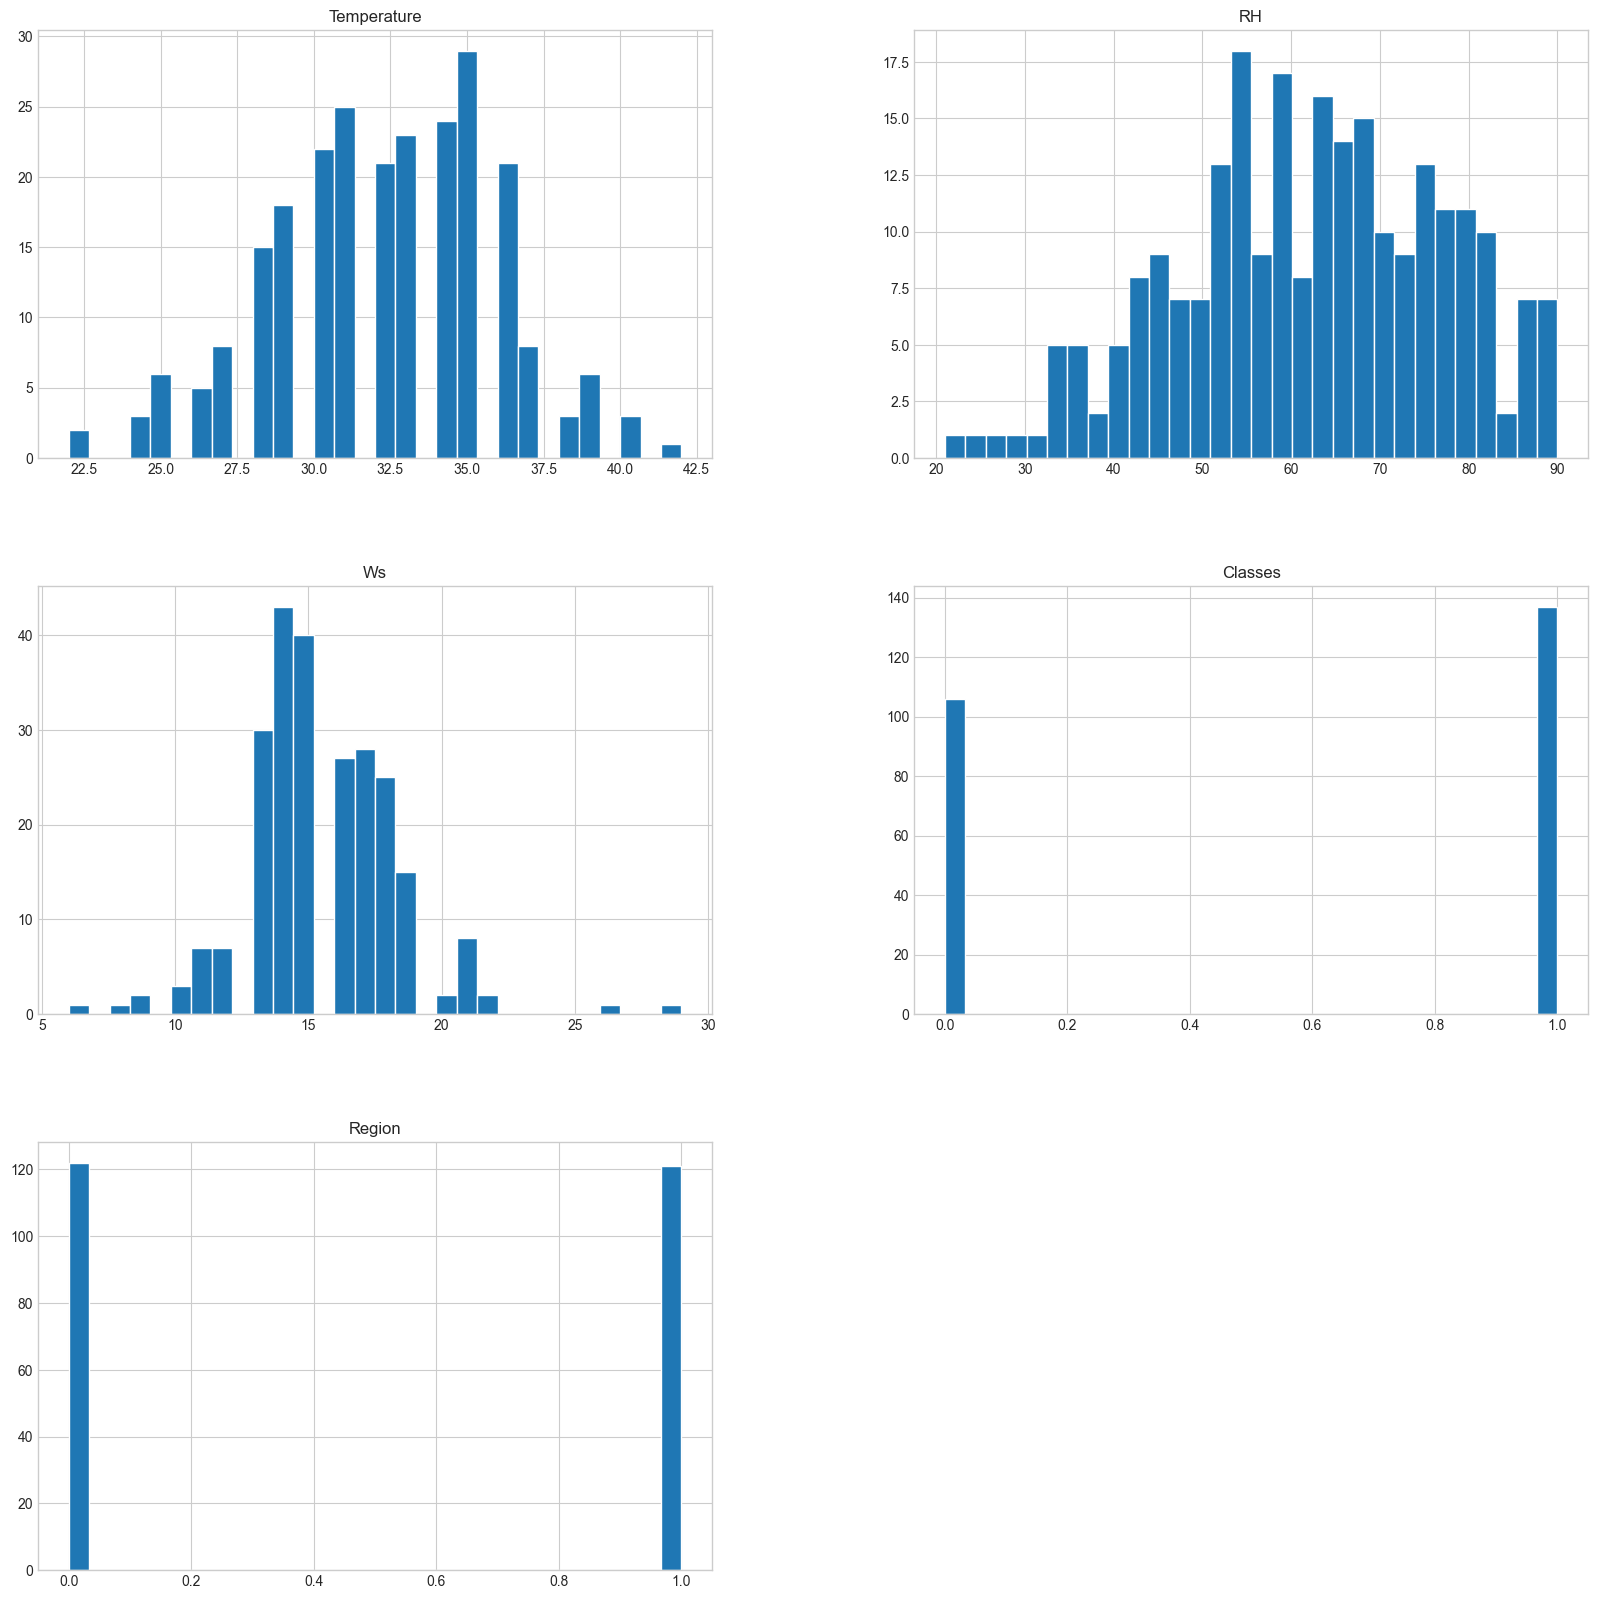

In [110]:
# Plot histograms for all features
plt.style.use('seaborn-v0_8-whitegrid')
df.hist(bins = 30, figsize=(20,20))
plt.show()

### 4.5. Pie Chart for 'Classes' Distribution

In [111]:
# Calculate the percentage of each class
percentage = df['Classes'].value_counts(normalize=True)*100

### 4.6. Plotting the Pie Chart

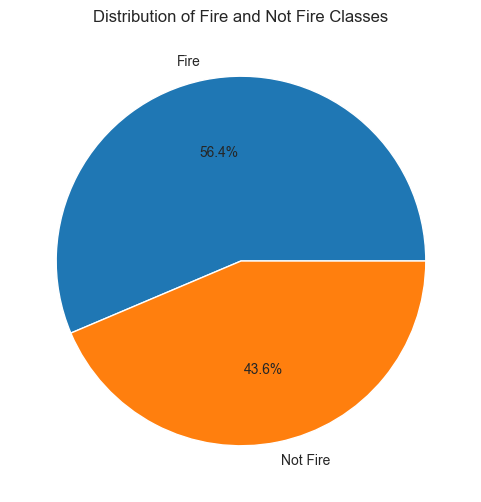

In [112]:
# Plot the pie chart
classlabels=['Fire','Not Fire']
plt.figure(figsize=(6,6))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title('Distribution of Fire and Not Fire Classes')
plt.show()

### 4.7. Correlation Analysis

In [113]:
# Calculate the correlation matrix
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


In [114]:
# Correlation of 'Classes' with other features
df.corr()['Classes'].sort_values(ascending=False)

Classes        1.000000
FFMC           0.769492
ISI            0.735197
FWI            0.719216
BUI            0.586639
DMC            0.585658
Temperature    0.516015
DC             0.511123
Region         0.162347
Ws            -0.069964
Rain          -0.379097
RH            -0.432161
Name: Classes, dtype: float64

In [115]:
# Correlation of 'FWI' with other features
df.corr()['FWI'].sort_values(ascending=False)

FWI            1.000000
ISI            0.922895
DMC            0.875864
BUI            0.857973
DC             0.739521
Classes        0.719216
FFMC           0.691132
Temperature    0.566670
Region         0.197102
Ws             0.032368
Rain          -0.324422
RH            -0.580957
Name: FWI, dtype: float64

<Axes: >

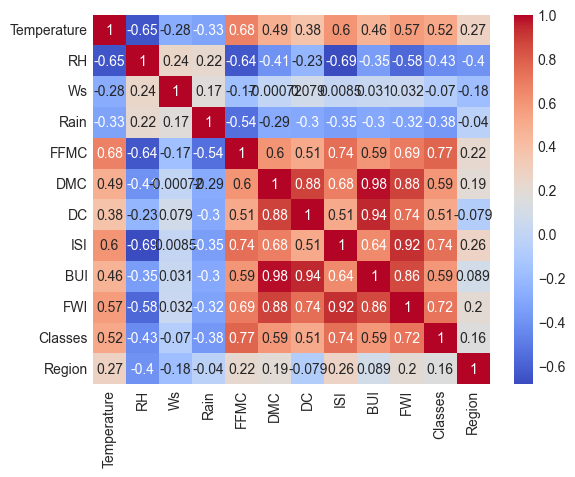

In [116]:
# Plot the correlation heatmap
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

### 4.8. Box Plot for FWI

<Axes: ylabel='FWI'>

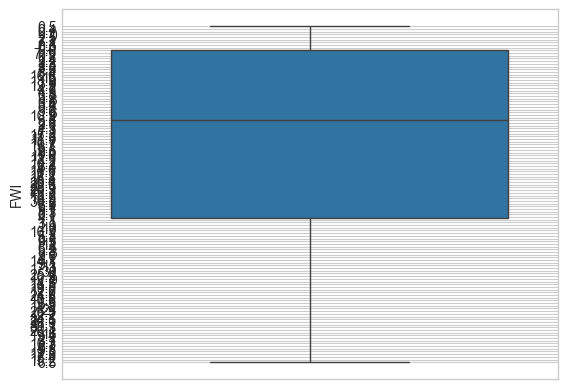

In [117]:
# Create a box plot for the 'FWI' column
sns.boxplot(df['FWI'])

In [118]:
# Display the first few rows of the original DataFrame
df_original.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [119]:
# Display the first few rows of the modified DataFrame
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,0,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,0,0


### 4.9. Bar Plot for Monthly Fire Analysis

In [120]:
# Get value counts of 'Classes' in the original DataFrame
df_original['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [121]:
# Encode 'Classes' in the original DataFrame
df_original['Classes']=np.where(df_original['Classes'].str.contains('not fire'),'not fire','fire')

In [122]:
# Get value counts of the encoded 'Classes' in the original DataFrame
df_original['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

### 4.10. Monthly Fire Analysis by Region

Text(0.5, 1.0, 'Fire Analysis of Sidi-Bel Abbes Region')

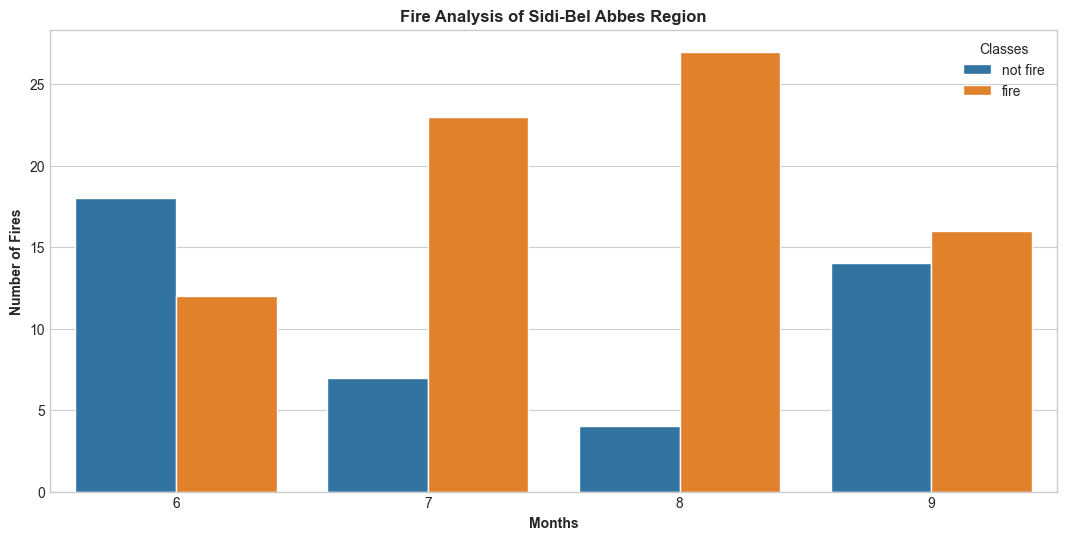

In [123]:
# Monthly fire analysis for Sidi-Bel Abbes Region
dftemp=df_original.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi-Bel Abbes Region",weight='bold')

Text(0.5, 1.0, 'Fire Analysis of Bejaia Region')

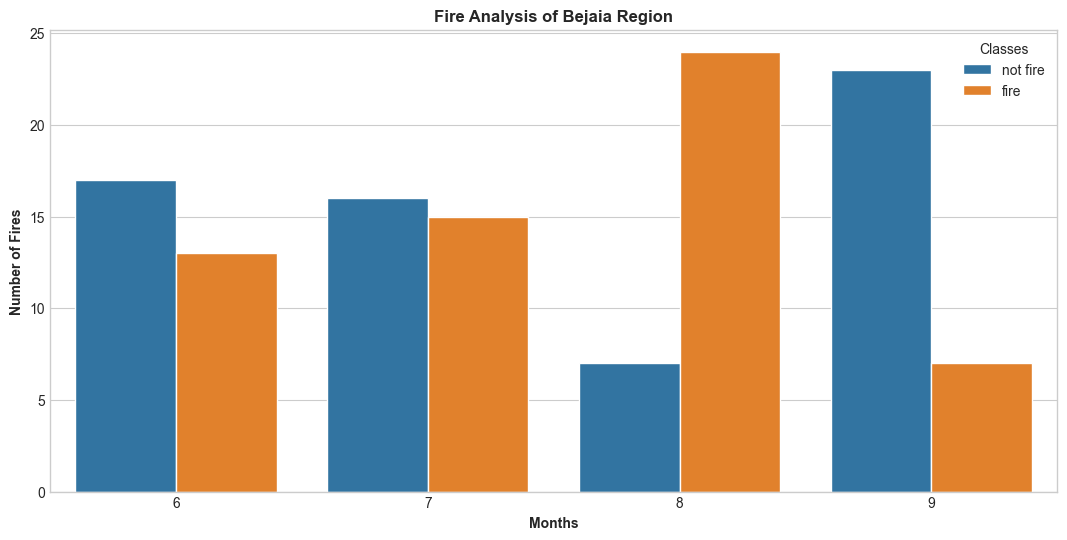

In [124]:
# Monthly fire analysis for Bejaia Region
dftemp=df_original.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Bejaia Region",weight='bold')

## 5. Observations from EDA

- August and September have the most forest fires in both regions.
- The majority of fires occur in June, July, and August.
- September has the fewest fires.